In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd

train_data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check total rows, column types, and missing values
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Survival rate by gender
train_data.groupby('Sex')['Survived'].mean()


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [5]:
# Survival rate by ticket class (1st, 2nd, 3rd)
train_data.groupby('Pclass')['Survived'].mean()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [6]:
from sklearn.ensemble import RandomForestClassifier

# 1. Load test dataset
test_data = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# 2. Select key features
features = ["Pclass", "Sex", "SibSp", "Parch"]
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])
y = train_data["Survived"]

# 3. Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)

# 4. Predict for test data
predictions = model.predict(X_test)

# 5. Save predictions to submission.csv
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Submission file successfully created!")


Submission file successfully created!


In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Load data
train_data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

full_data = [train_data, test_data]

# 2. Extract Title from Name
for dataset in full_data:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    dataset['Title'] = dataset['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare'
    )
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

# 3. Handle missing values
for dataset in full_data:
    dataset['Age'] = dataset.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
    dataset['Fare'] = dataset['Fare'].fillna(train_data['Fare'].median())
    dataset['Embarked'] = dataset['Embarked'].fillna('S')

# 4. Create new features: FamilySize and IsAlone
for dataset in full_data:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1

# 5. Feature selection and encoding
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

# Align columns between train and test sets
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)
y = train_data['Survived']

# 6. Train Random Forest model
model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=5, random_state=42)
model.fit(X, y)

# 7. Generate predictions and save submission file
predictions = model.predict(X_test)
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)

print("Advanced Feature Engineering model trained and submission.csv updated!")


<>:12: SyntaxWarning: invalid escape sequence '\.'
<>:12: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/2643978992.py:12: SyntaxWarning: invalid escape sequence '\.'
  dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Advanced Feature Engineering model trained and submission.csv updated!


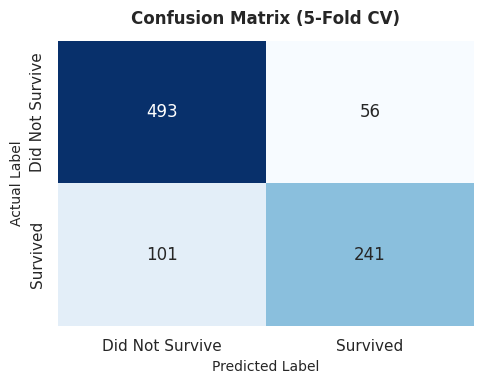

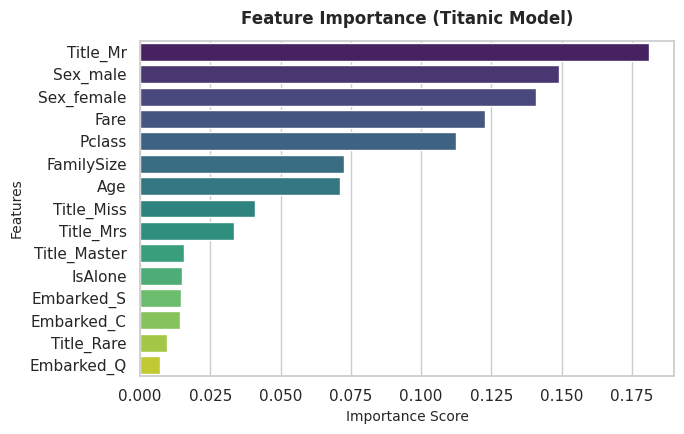

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Configure plot aesthetics
sns.set_theme(style="whitegrid")

# --------------------------------------------------
# 1. Confusion Matrix (Out-of-Fold Validation)
# --------------------------------------------------
y_pred = cross_val_predict(model, X, y, cv=5)
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived'],
    cbar=False
)
plt.title('Confusion Matrix (5-Fold CV)', fontsize=12, pad=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 2. Feature Importance (Sorted)
# --------------------------------------------------
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(
    x=feature_importance.values, 
    y=feature_importance.index, 
    hue=feature_importance.index,
    palette='viridis', 
    legend=False
)

plt.title('Feature Importance (Titanic Model)', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Importance Score', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
